 # OpenFire EDA — Notebook 1: California Fire History



 **Purpose:** Load the Cal Fire FRAP historical fire perimeters dataset,

 explore data quality and patterns, build an interactive exploration map,

 and produce a polished animation of California's fire history.



 **Sections:**

 - A: Data Acquisition & Loading

 - B: Data Quality & Basic EDA

 - C: Interactive Exploration App (Panel + pydeck) — *coming next*

 - D: Polished Video Export (matplotlib → mp4) — *coming next*



 **Data source:** CAL FIRE FRAP firep24_1 (released April 2025)

 https://www.fire.ca.gov/what-we-do/fire-resource-assessment-program/fire-perimeters

 =============================================================================

 SECTION A — Data Acquisition & Loading

 =============================================================================

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import contextily as cx
from pathlib import Path
from zipfile import ZipFile
from tqdm import tqdm
import requests
import warnings
import sys
import os

# Add parent dir to path so we can import config
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from config import *

warnings.filterwarnings("ignore", category=FutureWarning)

print(f"Data directory:   {DATA_DIR.resolve()}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")
print(f"Raster resolution: {RASTER_RESOLUTION_M}m")


Data directory:   /Users/tomas/Documents/02d-USF-MSDS/MSDS603/openfire/data
Output directory: /Users/tomas/Documents/02d-USF-MSDS/MSDS603/openfire/outputs/eda
Raster resolution: 1000m


In [2]:
import fiona

if not FIRE_PERIMETERS_GDB.exists():
    if FIRE_PERIMETERS_ZIP.exists():
        print(f"Extracting {FIRE_PERIMETERS_ZIP.name}...")
        with ZipFile(FIRE_PERIMETERS_ZIP, "r") as zf:
            zf.extractall(RAW_DIR)
        # Find the .gdb folder that was extracted
        gdb_folders = list(RAW_DIR.glob("*.gdb"))
        print(f"✓ Extracted {len(gdb_folders)} geodatabase(s):")
        for g in gdb_folders:
            print(f"   {g.name}")
    else:
        raise FileNotFoundError(
            f"Fire perimeters zip not found at: {FIRE_PERIMETERS_ZIP.resolve()}\n"
            f"Download from: https://frap.fire.ca.gov/mapping/gis-data/\n"
            f"Save as: {FIRE_PERIMETERS_ZIP.resolve()}"
        )
else:
    print(f"✓ Geodatabase already extracted: {FIRE_PERIMETERS_GDB.name}")


✓ Geodatabase already extracted: fire24_1.gdb


In [3]:
# A .gdb can contain multiple layers (fire perimeters, prescribed burns, etc.)
# Let's see what's inside.

# If the exact .gdb path from config doesn't exist, find it
gdb_path = FIRE_PERIMETERS_GDB
if not gdb_path.exists():
    gdb_folders = list(RAW_DIR.glob("*.gdb"))
    if gdb_folders:
        gdb_path = gdb_folders[0]
        print(f"⚠️  Expected {FIRE_PERIMETERS_GDB.name}, found {gdb_path.name}")
        print(f"   Update FIRE_PERIMETERS_GDB in config.py if needed.")
    else:
        raise FileNotFoundError("No .gdb folder found in data/raw/")

layers = fiona.listlayers(gdb_path)
print(f"Geodatabase: {gdb_path.name}")
print(f"Layers ({len(layers)}):")
for layer in layers:
    with fiona.open(gdb_path, layer=layer) as src:
        print(f"  {layer:<30} {len(src):>6,} features  |  {src.schema['geometry']}")

# Pick the fire perimeters layer (firep*), not prescribed burns (rxburn*)
fire_layer = FIRE_PERIMETERS_LAYER
if fire_layer not in layers:
    # Auto-detect: look for a layer with "firep" in the name
    for layer in layers:
        if "firep" in layer.lower():
            fire_layer = layer
            break
    else:
        fire_layer = layers[0]  # fallback to first layer
    print(f"\n⚠️  Layer '{FIRE_PERIMETERS_LAYER}' not found, using '{fire_layer}'")
else:
    print(f"\n→ Using layer: {fire_layer}")


Geodatabase: fire24_1.gdb
Layers (2):
  rxburn24_1                     10,675 features  |  MultiPolygon
  firep24_1                      22,810 features  |  MultiPolygon

→ Using layer: firep24_1


In [4]:
print(f"Loading layer '{fire_layer}' from {gdb_path.name}...")
gdf_raw = gpd.read_file(gdb_path, layer=fire_layer)

print(f"\n{'='*60}")
print(f"FRAP Fire Perimeters — Initial Load")
print(f"{'='*60}")
print(f"Records:    {len(gdf_raw):,}")
print(f"Columns:    {len(gdf_raw.columns)}")
print(f"CRS:        {gdf_raw.crs}")
print(f"Bounds:     {gdf_raw.total_bounds}")
print(f"Memory:     {gdf_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nColumn names:\n{list(gdf_raw.columns)}")


Loading layer 'firep24_1' from fire24_1.gdb...


/opt/anaconda3/envs/openfire/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(



FRAP Fire Perimeters — Initial Load
Records:    22,810
Columns:    20
CRS:        EPSG:3310
Bounds:     [-373237.5436 -604727.5643  539438.201   518283.7376]
Memory:     13.2 MB

Column names:
['YEAR_', 'STATE', 'AGENCY', 'UNIT_ID', 'FIRE_NAME', 'INC_NUM', 'IRWINID', 'ALARM_DATE', 'CONT_DATE', 'C_METHOD', 'CAUSE', 'COMPLEX_NAME', 'COMPLEX_ID', 'OBJECTIVE', 'GIS_ACRES', 'COMMENTS', 'FIRE_NUM', 'Shape_Length', 'Shape_Area', 'geometry']


In [5]:
print("Data types:")
print(gdf_raw.dtypes.to_string())
print(f"\nFirst 5 rows (non-geometry columns):")
gdf_raw.drop(columns="geometry").head()


Data types:
YEAR_                       float64
STATE                           str
AGENCY                          str
UNIT_ID                         str
FIRE_NAME                       str
INC_NUM                         str
IRWINID                         str
ALARM_DATE      datetime64[ms, UTC]
CONT_DATE       datetime64[ms, UTC]
C_METHOD                    float64
CAUSE                         int16
COMPLEX_NAME                    str
COMPLEX_ID                      str
OBJECTIVE                   float64
GIS_ACRES                   float32
COMMENTS                        str
FIRE_NUM                        str
Shape_Length                float64
Shape_Area                  float64
geometry                   geometry

First 5 rows (non-geometry columns):


,YEAR_,STATE,AGENCY,UNIT_ID,FIRE_NAME,INC_NUM,IRWINID,ALARM_DATE,CONT_DATE,C_METHOD,CAUSE,COMPLEX_NAME,COMPLEX_ID,OBJECTIVE,GIS_ACRES,COMMENTS,FIRE_NUM,Shape_Length,Shape_Area
0,2025.0,CA,CDF,LDF,PALISADES,00000738,{A7EA5D21-F882-44B8-BF64-44AB11059DC1},2025-01-07 00:00:00+00:00,2025-01-31 00:00:00+00:00,7.0,14,NaN,NaN,1.0,23448.882812,NaN,NaN,116028.197349,9.489426e+07
1,2025.0,CA,CDF,LAC,EATON,00009087,{72660ADC-B5EF-4D96-A33F-B4EA3740A4E3},2025-01-08 00:00:00+00:00,2025-01-31 00:00:00+00:00,7.0,14,NaN,NaN,1.0,14056.260742,NaN,NaN,86677.545056,5.688367e+07
2,2025.0,CA,CDF,ANF,HUGHES,00250270,{994072D2-E154-434A-BB95-6F6C94C40829},2025-01-22 00:00:00+00:00,2025-01-28 00:00:00+00:00,7.0,14,NaN,NaN,1.0,10396.798828,NaN,NaN,79554.126153,4.207435e+07
3,2025.0,CA,CCO,VNC,KENNETH,00003155,{842FB37B-7AC8-4700-BB9C-028BF753D149},2025-01-09 00:00:00+00:00,2025-02-04 00:00:00+00:00,2.0,14,NaN,NaN,1.0,998.737793,from OES Intel 24,NaN,12891.056545,4.041748e+06
4,2025.0,CA,CDF,LDF,HURST,00003294,{F4E810AD-CDF3-4ED4-B63F-03D43785BA7B},2025-01-07 00:00:00+00:00,2025-01-09 00:00:00+00:00,7.0,14,NaN,NaN,1.0,831.385498,NaN,NaN,13274.108148,3.364498e+06


In [6]:
# We need two versions:
#   - EPSG:3310 (CA Albers Equal Area) for area calculations, rasterization, static maps
#   - EPSG:4326 (WGS84 lat/lon) for web maps, pydeck, Folium

print(f"Original CRS: {gdf_raw.crs}")

# Reproject to CA Albers for area-preserving analysis
gdf = gdf_raw.to_crs(CRS_CA_ALBERS)
print(f"Reprojected to: {gdf.crs}  (California Albers Equal Area)")
print(f"New bounds: {gdf.total_bounds}")


# =============================================================================
# SECTION B — Data Quality & Basic EDA
# =============================================================================


Original CRS: EPSG:3310
Reprojected to: EPSG:3310  (California Albers Equal Area)
New bounds: [-373237.5436 -604727.5643  539438.201   518283.7376]


In [7]:
# FRAP column names can vary between releases. Let's check what we have
# and standardize the key fields we need.

# Print all columns with sample values to understand what we're working with
print("Column inventory:")
print("-" * 70)
for col in gdf.columns:
    if col == "geometry":
        continue
    non_null = gdf[col].dropna()
    n_null = gdf[col].isna().sum()
    sample = non_null.iloc[0] if len(non_null) > 0 else "ALL NULL"
    print(f"  {col:<20} nulls={n_null:>5}  sample: {sample}")


Column inventory:
----------------------------------------------------------------------
  YEAR_                nulls=   77  sample: 2025.0
  STATE                nulls=    0  sample: CA
  AGENCY               nulls=   49  sample: CDF
  UNIT_ID              nulls=   61  sample: LDF
  FIRE_NAME            nulls=   62  sample: PALISADES
  INC_NUM              nulls=  971  sample: 00000738
  IRWINID              nulls=19074  sample: {A7EA5D21-F882-44B8-BF64-44AB11059DC1}
  ALARM_DATE           nulls= 5396  sample: 2025-01-07 00:00:00+00:00
  CONT_DATE            nulls=12630  sample: 2025-01-31 00:00:00+00:00
  C_METHOD             nulls=12102  sample: 7.0
  CAUSE                nulls=    0  sample: 14
  COMPLEX_NAME         nulls=22199  sample: FRESNO JUNE LIGHTNING COMPLEX
  COMPLEX_ID           nulls=22243  sample: AFC5730E-2C3A-464B-8BCE-3967545980D3
  OBJECTIVE            nulls=  271  sample: 1.0
  GIS_ACRES            nulls=    0  sample: 23448.8828125
  COMMENTS             nulls=19

In [8]:
# Key fields we expect:
#   YEAR_ — fire year (integer, should always be present)
#   ALARM_DATE — date fire was reported (datetime, often NULL for old fires)
#   CONT_DATE — date fire was contained (datetime, often NULL)
#   FIRE_NAME — name of the fire
#   GIS_ACRES — acreage from GIS polygon measurement
#   CAUSE — fire cause code

# Ensure YEAR_ is integer
if "YEAR_" in gdf.columns:
    gdf["year"] = pd.to_numeric(gdf["YEAR_"], errors="coerce").astype("Int64")
elif "YEAR" in gdf.columns:
    gdf["year"] = pd.to_numeric(gdf["YEAR"], errors="coerce").astype("Int64")
else:
    print("⚠️  No YEAR column found! Available columns:", list(gdf.columns))

# Parse ALARM_DATE
date_col = None
for candidate in ["ALARM_DATE", "ALARMDATE", "alarm_date"]:
    if candidate in gdf.columns:
        date_col = candidate
        break

if date_col:
    gdf["alarm_date"] = pd.to_datetime(gdf[date_col], errors="coerce")
    gdf["alarm_month"] = gdf["alarm_date"].dt.to_period("M")
    print(f"Parsed alarm dates from '{date_col}'")
else:
    gdf["alarm_date"] = pd.NaT
    gdf["alarm_month"] = pd.NaT
    print("⚠️  No ALARM_DATE column found!")

# Parse CONT_DATE similarly
for candidate in ["CONT_DATE", "CONTDATE", "cont_date"]:
    if candidate in gdf.columns:
        gdf["cont_date"] = pd.to_datetime(gdf[candidate], errors="coerce")
        break
else:
    gdf["cont_date"] = pd.NaT

# Standardize fire name
for candidate in ["FIRE_NAME", "FIRENAME", "fire_name", "FIRE NAME"]:
    if candidate in gdf.columns:
        gdf["fire_name"] = gdf[candidate].fillna("UNNAMED")
        break
else:
    gdf["fire_name"] = "UNNAMED"

# Standardize acreage
for candidate in ["GIS_ACRES", "GISACRES", "gis_acres", "Shape_Area"]:
    if candidate in gdf.columns:
        gdf["acres"] = pd.to_numeric(gdf[candidate], errors="coerce")
        break
else:
    # Compute from geometry if no acreage column
    gdf["acres"] = gdf.geometry.area / 4046.86  # sq meters to acres
    print("Computed acreage from geometry (no GIS_ACRES column found)")

# Standardize cause
for candidate in ["CAUSE", "cause"]:
    if candidate in gdf.columns:
        gdf["cause"] = gdf[candidate]
        break
else:
    gdf["cause"] = np.nan

print(f"\nYear range: {gdf['year'].min()} — {gdf['year'].max()}")
print(f"Fires with exact alarm date: {gdf['alarm_date'].notna().sum():,} / {len(gdf):,} "
      f"({gdf['alarm_date'].notna().mean():.1%})")
print(f"Fires with acreage data:     {gdf['acres'].notna().sum():,} / {len(gdf):,}")


Parsed alarm dates from 'ALARM_DATE'

Year range: 1878 — 2025
Fires with exact alarm date: 17,414 / 22,810 (76.3%)
Fires with acreage data:     22,810 / 22,810


/var/folders/8q/48hstyms4z79cf6rxhybh5340000gn/T/ipykernel_28224/385570398.py:26: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  gdf["alarm_month"] = gdf["alarm_date"].dt.to_period("M")


In [9]:
decade_completeness = (
    gdf.assign(decade=lambda x: (x["year"] // 10) * 10)
    .groupby("decade")
    .agg(
        n_fires=("year", "size"),
        has_alarm_date=("alarm_date", lambda s: s.notna().sum()),
        total_acres=("acres", "sum"),
    )
    .assign(pct_with_date=lambda x: x["has_alarm_date"] / x["n_fires"] * 100)
)

print("\nFire records by decade:")
print("=" * 75)
print(f"{'Decade':<10} {'Fires':>8} {'With Date':>12} {'% Dated':>10} {'Total Acres':>15}")
print("-" * 75)
for decade, row in decade_completeness.iterrows():
    if pd.isna(decade):
        continue
    print(
        f"{int(decade)}s{'':<5} {int(row['n_fires']):>8,} "
        f"{int(row['has_alarm_date']):>12,} "
        f"{row['pct_with_date']:>9.1f}% "
        f"{row['total_acres']:>15,.0f}"
    )



Fire records by decade:
Decade        Fires    With Date    % Dated     Total Acres
---------------------------------------------------------------------------
1870s             1            0       0.0%          59,469
1890s             7            3      42.9%          36,404
1900s            70            9      12.9%          89,124
1910s         1,324          249      18.8%       1,671,692
1920s         1,479          320      21.6%       2,925,772
1930s         1,157          432      37.3%       1,605,232
1940s         1,155          481      41.6%       1,959,130
1950s         1,819        1,463      80.4%       2,844,982
1960s         1,276          965      75.6%       2,075,062
1970s         1,879        1,548      82.4%       2,606,294
1980s         2,208        1,919      86.9%       3,080,518
1990s         1,992        1,712      85.9%       3,348,844
2000s         2,905        2,869      98.8%       6,528,778
2010s         3,425        3,408      99.5%       6,898,907

In [10]:
# This is the key column for animation: month-level where we have dates,
# year-level where we don't.

def make_time_bin(row):
    """Return 'YYYY-MM' if alarm_date is available, else 'YYYY'."""
    if pd.notna(row["alarm_date"]):
        return row["alarm_date"].strftime("%Y-%m")
    elif pd.notna(row["year"]):
        return str(int(row["year"]))
    return None

gdf["time_bin"] = gdf.apply(make_time_bin, axis=1)

# Also create a sortable numeric key for animation ordering
def time_bin_sort_key(tb):
    """Convert time_bin to a float for sorting: YYYY.0 or YYYY.MM"""
    if tb is None:
        return 0.0
    if "-" in str(tb):
        parts = str(tb).split("-")
        return float(parts[0]) + float(parts[1]) / 100
    return float(tb)

gdf["time_sort"] = gdf["time_bin"].apply(time_bin_sort_key)

print(f"Unique time bins: {gdf['time_bin'].nunique():,}")
print(f"\nSample time bins (first 10 sorted):")
for tb in sorted(gdf["time_bin"].dropna().unique(), key=time_bin_sort_key)[:10]:
    print(f"  {tb}")
print("  ...")
for tb in sorted(gdf["time_bin"].dropna().unique(), key=time_bin_sort_key)[-5:]:
    print(f"  {tb}")


Unique time bins: 1,144

Sample time bins (first 10 sorted):
  1878
  1895
  1896
  1898
  1898-04
  1898-09
  1900
  1902-08
  1903
  1903-10
  ...
  2024-09
  2024-10
  2024-11
  2024-12
  2025-01


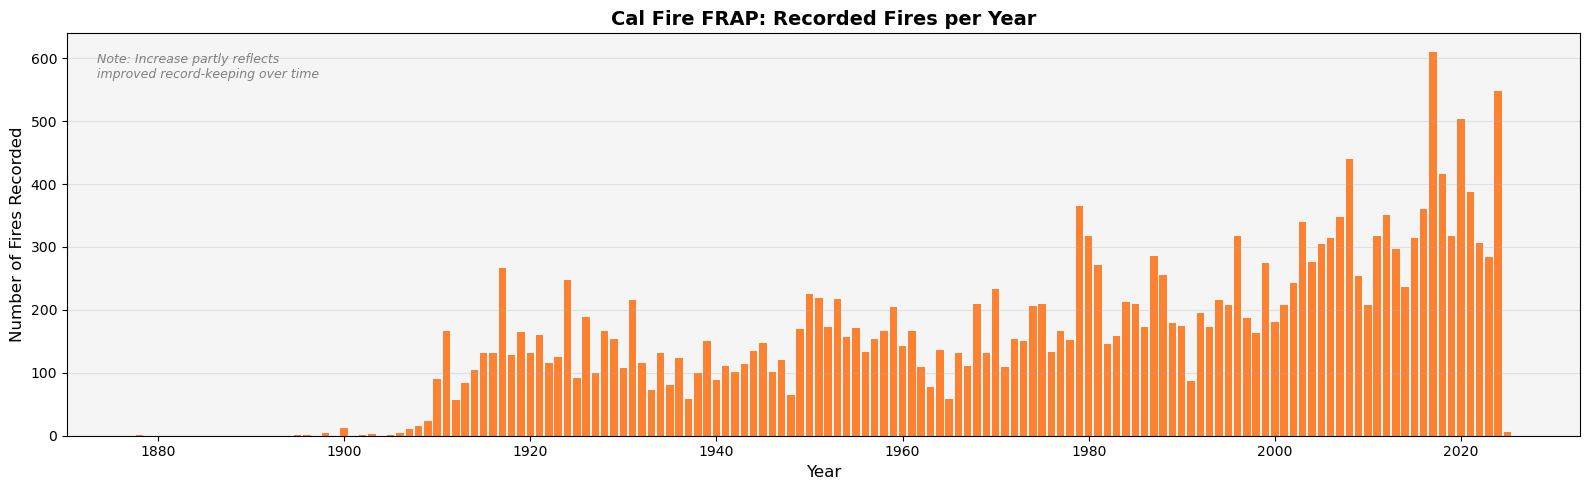

In [11]:
fig, ax = plt.subplots(figsize=(16, 5))

fires_per_year = gdf.groupby("year").size()
ax.bar(fires_per_year.index.astype(float), fires_per_year.values,
       color="#ff6600", alpha=0.8, width=0.8)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Number of Fires Recorded", fontsize=12)
ax.set_title("Cal Fire FRAP: Recorded Fires per Year", fontsize=14, fontweight="bold")
ax.set_facecolor("#f5f5f5")
ax.grid(axis="y", alpha=0.3)
ax.annotate(
    "Note: Increase partly reflects\nimproved record-keeping over time",
    xy=(0.02, 0.95), xycoords="axes fraction", fontsize=9,
    va="top", color="gray", fontstyle="italic",
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fires_per_year.png", dpi=150, bbox_inches="tight")
plt.show()


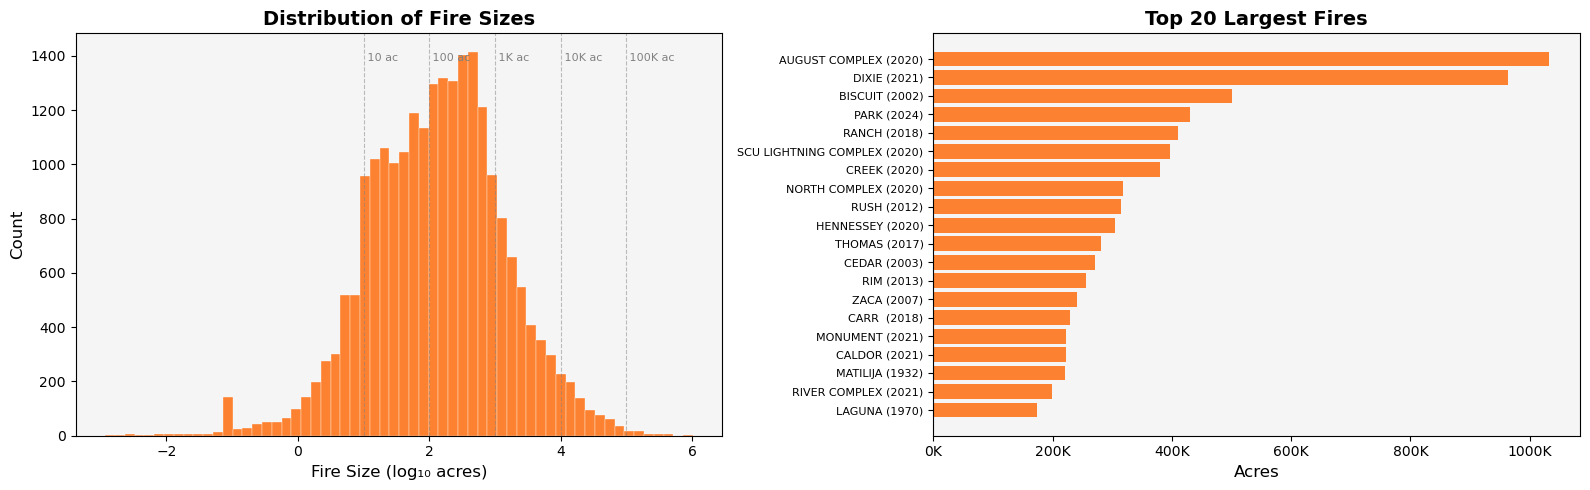


Top 20 Largest Fires:
            fire_name  year        acres
       AUGUST COMPLEX  2020 1.032700e+06
                DIXIE  2021 9.634054e+05
              BISCUIT  2002 5.010820e+05
                 PARK  2024 4.296028e+05
                RANCH  2018 4.102025e+05
SCU LIGHTNING COMPLEX  2020 3.968245e+05
                CREEK  2020 3.798424e+05
        NORTH COMPLEX  2020 3.187972e+05
                 RUSH  2012 3.155115e+05
            HENNESSEY  2020 3.053519e+05
               THOMAS  2017 2.817909e+05
                CEDAR  2003 2.706860e+05
                  RIM  2013 2.561755e+05
                 ZACA  2007 2.403587e+05
                CARR   2018 2.296514e+05
             MONUMENT  2021 2.231079e+05
               CALDOR  2021 2.217864e+05
             MATILIJA  1932 2.199993e+05
        RIVER COMPLEX  2021 1.993541e+05
               LAGUNA  1970 1.741615e+05


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of fire sizes (log scale)
ax = axes[0]
valid_acres = gdf["acres"].dropna()
valid_acres = valid_acres[valid_acres > 0]
ax.hist(np.log10(valid_acres), bins=60, color="#ff6600", alpha=0.8, edgecolor="white", linewidth=0.3)
ax.set_xlabel("Fire Size (log₁₀ acres)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Distribution of Fire Sizes", fontsize=14, fontweight="bold")
# Add reference lines
for threshold, label in [(10, "10 ac"), (100, "100 ac"), (1000, "1K ac"),
                          (10000, "10K ac"), (100000, "100K ac")]:
    ax.axvline(np.log10(threshold), color="gray", linestyle="--", alpha=0.5, linewidth=0.8)
    ax.text(np.log10(threshold), ax.get_ylim()[1] * 0.95, f" {label}", fontsize=8,
            color="gray", va="top")
ax.set_facecolor("#f5f5f5")

# Top 20 largest fires
ax = axes[1]
top_fires = (
    gdf.nlargest(20, "acres")[["fire_name", "year", "acres"]]
    .reset_index(drop=True)
)
ax.barh(range(len(top_fires)), top_fires["acres"],
        color="#ff6600", alpha=0.8)
ax.set_yticks(range(len(top_fires)))
ax.set_yticklabels(
    [f"{row.fire_name} ({int(row.year)})" for _, row in top_fires.iterrows()],
    fontsize=8,
)
ax.set_xlabel("Acres", fontsize=12)
ax.set_title("Top 20 Largest Fires", fontsize=14, fontweight="bold")
ax.invert_yaxis()
ax.set_facecolor("#f5f5f5")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fire_size_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 20 Largest Fires:")
print(top_fires.to_string(index=False))


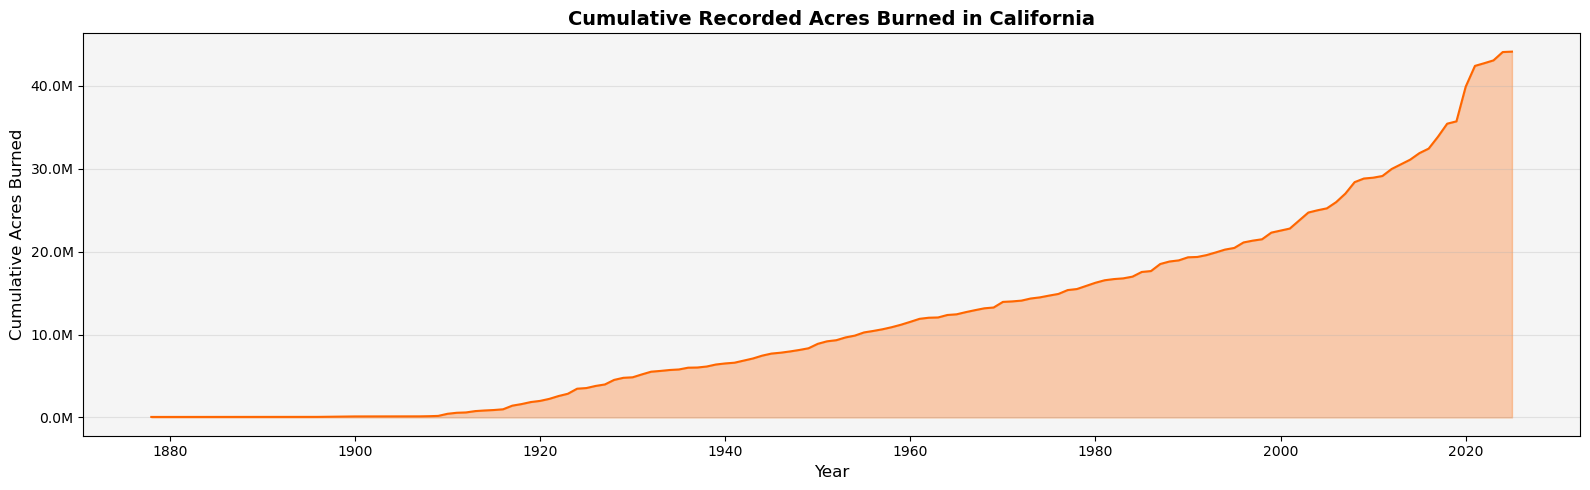

In [13]:
cumulative = (
    gdf.groupby("year")["acres"]
    .sum()
    .sort_index()
    .cumsum()
)

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(cumulative.index.astype(float), cumulative.values,
                color="#ff6600", alpha=0.3)
ax.plot(cumulative.index.astype(float), cumulative.values,
        color="#ff6600", linewidth=1.5)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Cumulative Acres Burned", fontsize=12)
ax.set_title("Cumulative Recorded Acres Burned in California", fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.set_facecolor("#f5f5f5")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cumulative_acres.png", dpi=150, bbox_inches="tight")
plt.show()


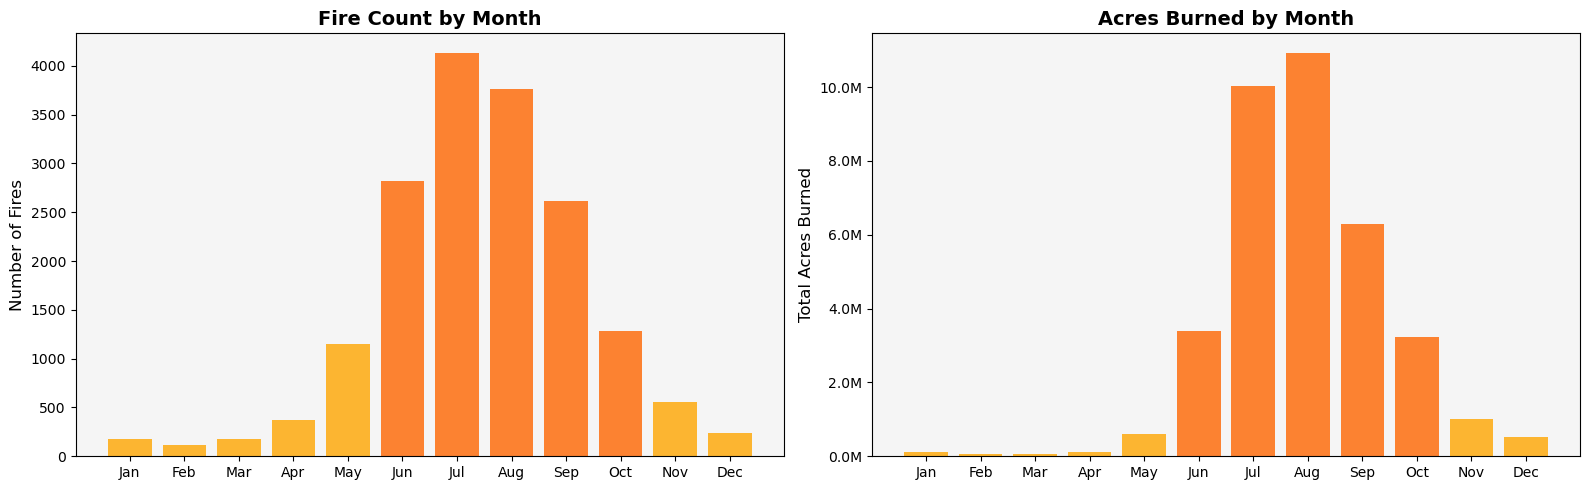

In [14]:
dated_fires = gdf[gdf["alarm_date"].notna()].copy()
dated_fires["month"] = dated_fires["alarm_date"].dt.month

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Count by month
ax = axes[0]
month_counts = dated_fires.groupby("month").size()
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
colors = ["#ff6600" if m in [6, 7, 8, 9, 10] else "#ffa500" for m in range(1, 13)]
ax.bar(range(1, 13), [month_counts.get(m, 0) for m in range(1, 13)],
       color=colors, alpha=0.8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_ylabel("Number of Fires", fontsize=12)
ax.set_title("Fire Count by Month", fontsize=14, fontweight="bold")
ax.set_facecolor("#f5f5f5")

# Acres by month
ax = axes[1]
month_acres = dated_fires.groupby("month")["acres"].sum()
ax.bar(range(1, 13), [month_acres.get(m, 0) for m in range(1, 13)],
       color=colors, alpha=0.8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_ylabel("Total Acres Burned", fontsize=12)
ax.set_title("Acres Burned by Month", fontsize=14, fontweight="bold")
ax.set_facecolor("#f5f5f5")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fire_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()


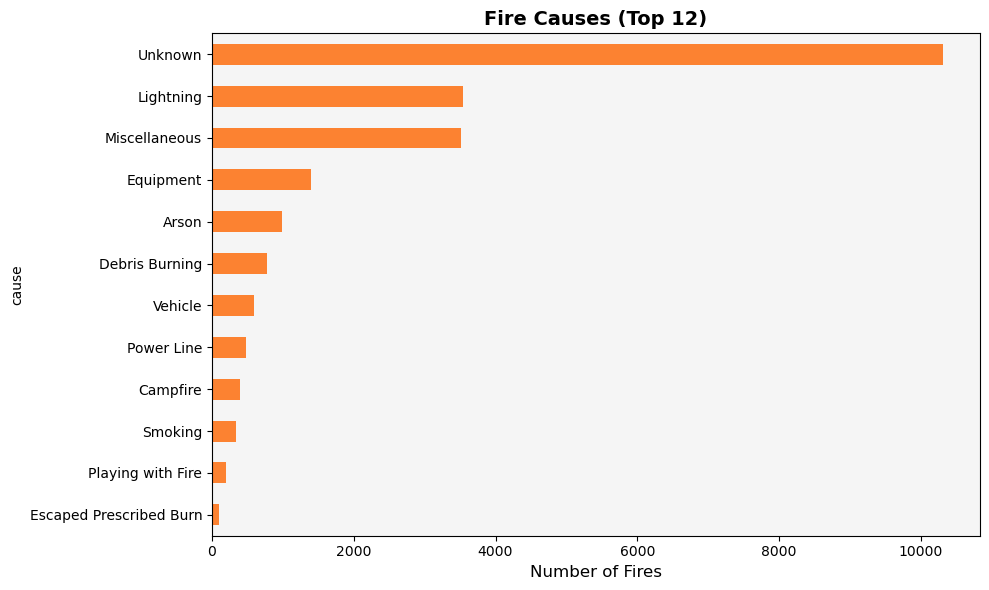

In [15]:
if gdf["cause"].notna().any():
    # FRAP cause codes: 1=Lightning, 2=Equipment Use, 4=Campfire, 5=Debris,
    # 6=Railroad, 7=Arson, 9=Miscellaneous, 10=Vehicle, 11=Power Line,
    # 14=Unknown/Unidentified, etc.
    cause_map = {
        1: "Lightning", 2: "Equipment", 3: "Smoking", 4: "Campfire",
        5: "Debris Burning", 6: "Railroad", 7: "Arson", 8: "Playing with Fire",
        9: "Miscellaneous", 10: "Vehicle", 11: "Power Line", 12: "Firefighter Training",
        13: "Non-Firefighter Training", 14: "Unknown", 15: "Structure",
        16: "Aircraft", 17: "Volcanic", 18: "Escaped Prescribed Burn", 19: "Illegal Alien Campfire"
    }

    cause_counts = (
        gdf["cause"]
        .dropna()
        .astype(int)
        .map(cause_map)
        .fillna("Other")
        .value_counts()
        .head(12)
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    cause_counts.plot(kind="barh", ax=ax, color="#ff6600", alpha=0.8)
    ax.set_xlabel("Number of Fires", fontsize=12)
    ax.set_title("Fire Causes (Top 12)", fontsize=14, fontweight="bold")
    ax.invert_yaxis()
    ax.set_facecolor("#f5f5f5")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "fire_causes.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No cause data available in this release.")


In [16]:
def get_california_boundary() -> gpd.GeoDataFrame:
    """Get California state boundary. Downloads Census TIGER if needed."""
    ca_shp = CA_BOUNDARY_PATH / "california.shp"

    if ca_shp.exists():
        print(f"✓ California boundary already cached")
        return gpd.read_file(ca_shp)

    # Try downloading Census TIGER state boundaries
    tiger_zip = RAW_DIR / "tl_2023_us_state.zip"
    if not tiger_zip.exists():
        print("Downloading California state boundary from Census TIGER...")
        try:
            resp = requests.get(CA_BOUNDARY_URL, stream=True, timeout=60)
            resp.raise_for_status()
            with open(tiger_zip, "wb") as f:
                for chunk in resp.iter_content(chunk_size=8192):
                    f.write(chunk)
            print(f"✓ Downloaded: {tiger_zip.name}")
        except Exception as e:
            print(f"⚠️  Download failed: {e}")
            tiger_zip = None

    if tiger_zip and tiger_zip.exists():
        states = gpd.read_file(f"zip://{tiger_zip}")
        ca = states[states["STUSPS"] == "CA"].copy()
        CA_BOUNDARY_PATH.mkdir(parents=True, exist_ok=True)
        ca.to_file(ca_shp)
        print(f"✓ Extracted California boundary")
        return ca

    # Fallback: extract CA outline from fire perimeters convex hull
    print("⚠️  Using convex hull of fire perimeters as fallback boundary")
    return gpd.GeoDataFrame(
        geometry=[gdf.to_crs(CRS_WGS84).unary_union.convex_hull],
        crs=CRS_WGS84,
    )


ca_boundary = get_california_boundary().to_crs(CRS_CA_ALBERS)
print(f"California boundary CRS: {ca_boundary.crs}")


✓ California boundary already cached
California boundary CRS: EPSG:3310


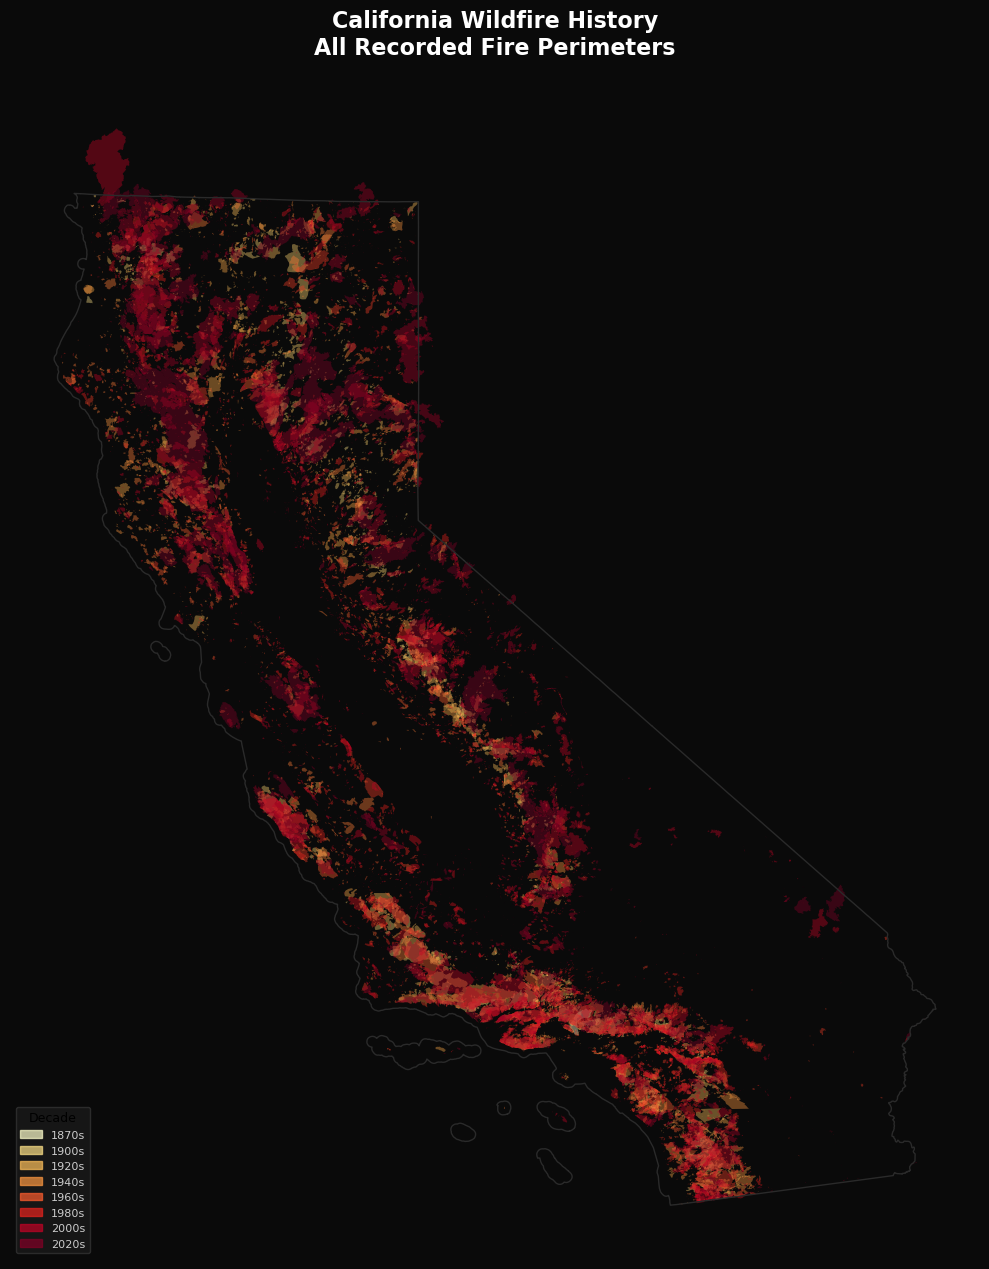

In [17]:
fig, ax = plt.subplots(figsize=(10, 14))
ax.set_facecolor(BG_COLOR)
fig.patch.set_facecolor(BG_COLOR)

# Draw California outline
ca_boundary.boundary.plot(ax=ax, color=CA_OUTLINE_COLOR, linewidth=1)

# Color fires by decade
decade_cmap = plt.cm.YlOrRd
gdf_plot = gdf[gdf["year"].notna()].copy()
gdf_plot["decade"] = (gdf_plot["year"] // 10) * 10

# Normalize decades to colormap range
min_decade = gdf_plot["decade"].min()
max_decade = gdf_plot["decade"].max()

for decade, group in gdf_plot.groupby("decade"):
    if pd.isna(decade):
        continue
    norm_val = (decade - min_decade) / (max_decade - min_decade + 1)
    color = decade_cmap(norm_val)
    group.plot(ax=ax, color=color, alpha=0.4, linewidth=0)

# Legend
unique_decades = sorted(gdf_plot["decade"].dropna().unique())
# Show every other decade to avoid clutter
legend_decades = unique_decades[::2]
legend_patches = [
    mpatches.Patch(
        color=decade_cmap((d - min_decade) / (max_decade - min_decade + 1)),
        label=f"{int(d)}s",
        alpha=0.7,
    )
    for d in legend_decades
]
ax.legend(
    handles=legend_patches, loc="lower left", fontsize=8,
    facecolor="#1a1a1a", edgecolor="#333", labelcolor=TEXT_COLOR,
    title="Decade", title_fontsize=9,
)

ax.set_title(
    "California Wildfire History\nAll Recorded Fire Perimeters",
    fontsize=16, fontweight="bold", color=YEAR_TEXT_COLOR, pad=15,
)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "all_fires_by_decade.png", dpi=200, bbox_inches="tight",
    facecolor=BG_COLOR,
)
plt.show()


In [18]:
print("\n" + "=" * 60)
print("SUMMARY: Fires by era (to help choose animation start year)")
print("=" * 60)

eras = [
    ("Pre-1900", gdf[gdf["year"] < 1900]),
    ("1900–1919", gdf[(gdf["year"] >= 1900) & (gdf["year"] < 1920)]),
    ("1920–1949", gdf[(gdf["year"] >= 1920) & (gdf["year"] < 1950)]),
    ("1950–1979", gdf[(gdf["year"] >= 1950) & (gdf["year"] < 1980)]),
    ("1980–1999", gdf[(gdf["year"] >= 1980) & (gdf["year"] < 2000)]),
    ("2000–2024", gdf[gdf["year"] >= 2000]),
]

for label, subset in eras:
    dated_pct = subset["alarm_date"].notna().mean() * 100 if len(subset) > 0 else 0
    print(
        f"  {label:<12}  {len(subset):>6,} fires  |  "
        f"{subset['acres'].sum():>12,.0f} acres  |  "
        f"{dated_pct:>5.1f}% with exact dates"
    )

print(f"\n→ Current animation start year in config: {ANIMATION_START_YEAR}")
print(f"  (Change ANIMATION_START_YEAR in config.py to adjust)")



SUMMARY: Fires by era (to help choose animation start year)
  Pre-1900           8 fires  |        95,873 acres  |   37.5% with exact dates
  1900–1919      1,394 fires  |     1,760,817 acres  |   18.5% with exact dates
  1920–1949      3,791 fires  |     6,490,134 acres  |   32.5% with exact dates
  1950–1979      4,974 fires  |     7,526,338 acres  |   79.9% with exact dates
  1980–1999      4,200 fires  |     6,429,362 acres  |   86.5% with exact dates
  2000–2024      8,366 fires  |    21,843,732 acres  |   99.4% with exact dates

→ Current animation start year in config: 2000
  (Change ANIMATION_START_YEAR in config.py to adjust)


In [19]:
print("Simplifying geometries for faster rendering...")
gdf_simplified = gdf.copy()
gdf_simplified["geometry"] = gdf.geometry.simplify(
    tolerance=SIMPLIFY_TOLERANCE_M, preserve_topology=True
)

# Quick size comparison
orig_size = gdf.geometry.memory_usage(deep=True) / 1e6
simp_size = gdf_simplified.geometry.memory_usage(deep=True) / 1e6
print(f"  Geometry memory: {orig_size:.1f} MB → {simp_size:.1f} MB")

# Drop columns that GeoPackage can't serialize
cols_to_drop = [c for c in ["alarm_month", "time_sort", "alarm_date", "cont_date", "fire_name", "cause"] if c in gdf_simplified.columns]
gdf_simplified = gdf_simplified.drop(columns=cols_to_drop)

# Save to processed dir for use by other notebooks
processed_path = PROCESSED_DIR / "fire_perimeters_processed.gpkg"
gdf_simplified.to_file(processed_path, driver="GPKG")
print(f"✓ Saved processed data: {processed_path}")
print(f"  File size: {processed_path.stat().st_size / 1e6:.1f} MB")

# Also save a WGS84 version for web maps
gdf_wgs84 = gdf_simplified.to_crs(CRS_WGS84)
wgs84_path = PROCESSED_DIR / "fire_perimeters_wgs84.gpkg"
gdf_wgs84.to_file(wgs84_path, driver="GPKG")
print(f"✓ Saved WGS84 version: {wgs84_path}")

print(f"\n{'='*60}")
print(f"Section B complete! Ready for interactive exploration (Section C).")
print(f"{'='*60}")
print(f"\nKey numbers:")
print(f"  Total fire records:    {len(gdf):,}")
print(f"  Year range:            {gdf['year'].min()} — {gdf['year'].max()}")
print(f"  With exact dates:      {gdf['alarm_date'].notna().sum():,}")
print(f"  Unique time bins:      {gdf['time_bin'].nunique():,}")
print(f"  Total acres in dataset: {gdf['acres'].sum():,.0f}")

Simplifying geometries for faster rendering...


/opt/anaconda3/envs/openfire/lib/python3.11/site-packages/shapely/constructive.py:1177: RuntimeWarning: invalid value encountered in simplify_preserve_topology
  return lib.simplify_preserve_topology(geometry, tolerance, **kwargs)


  Geometry memory: 0.2 MB → 0.2 MB
✓ Saved processed data: /Users/tomas/Documents/02d-USF-MSDS/MSDS603/openfire/data/processed/fire_perimeters_processed.gpkg
  File size: 9.6 MB
✓ Saved WGS84 version: /Users/tomas/Documents/02d-USF-MSDS/MSDS603/openfire/data/processed/fire_perimeters_wgs84.gpkg

Section B complete! Ready for interactive exploration (Section C).

Key numbers:
  Total fire records:    22,810
  Year range:            1878 — 2025
  With exact dates:      17,414
  Unique time bins:      1,144
  Total acres in dataset: 44,184,184


# Section C — Interactive Exploration App (Panel + pydeck)

**What this section builds:**
- An animated map of California fire history with interactive controls
- Speed slider, year-range filter, acreage filter, fade-mode toggle
- Uses Panel for widgets + matplotlib for map rendering

**Prerequisites:** Run Sections A & B first (needs `gdf` and `ca_boundary` in memory)

In [20]:
import panel as pn
pn.extension()  # Initialize Panel in the notebook

# Fix invalid geometries (some old perimeters have self-intersections)
n_invalid = (~gdf.geometry.is_valid).sum()
if n_invalid > 0:
    print(f"Fixing {n_invalid} invalid geometries...")
    gdf["geometry"] = gdf.geometry.make_valid()
    print(f"✓ All geometries now valid: {gdf.geometry.is_valid.all()}")
else:
    print("✓ All geometries already valid")

# Pre-simplify for faster interactive rendering
gdf_interactive = gdf.copy()
gdf_interactive["geometry"] = gdf_interactive.geometry.simplify(
    tolerance=SIMPLIFY_TOLERANCE_M, preserve_topology=True
)

# Pre-compute: group fires by time_bin for fast frame lookup
# Each frame = one time_bin (a year like "1985" or a month like "2020-07")
sorted_bins = sorted(
    gdf_interactive["time_bin"].dropna().unique(),
    key=time_bin_sort_key,
)

# Build a dict: time_bin -> list of row indices for fast lookup
bin_to_indices = {}
for tb in sorted_bins:
    bin_to_indices[tb] = gdf_interactive[gdf_interactive["time_bin"] == tb].index.tolist()

print(f"Total time bins (frames): {len(sorted_bins)}")
print(f"Bins range: {sorted_bins[0]} → {sorted_bins[-1]}")

# Pre-compute bounds for consistent axis limits
bounds = ca_boundary.total_bounds  # [minx, miny, maxx, maxy]
print(f"Map bounds: {bounds}")

Fixing 393 invalid geometries...
✓ All geometries now valid: True


/opt/anaconda3/envs/openfire/lib/python3.11/site-packages/shapely/constructive.py:1177: RuntimeWarning: invalid value encountered in simplify_preserve_topology
  return lib.simplify_preserve_topology(geometry, tolerance, **kwargs)


Total time bins (frames): 1144
Bins range: 1878 → 2025-01
Map bounds: [-380101.0656607  -605252.61217882  540037.54685041  450446.71159829]


Adaptive bins (monthly where possible): 1144
Yearly bins: 128


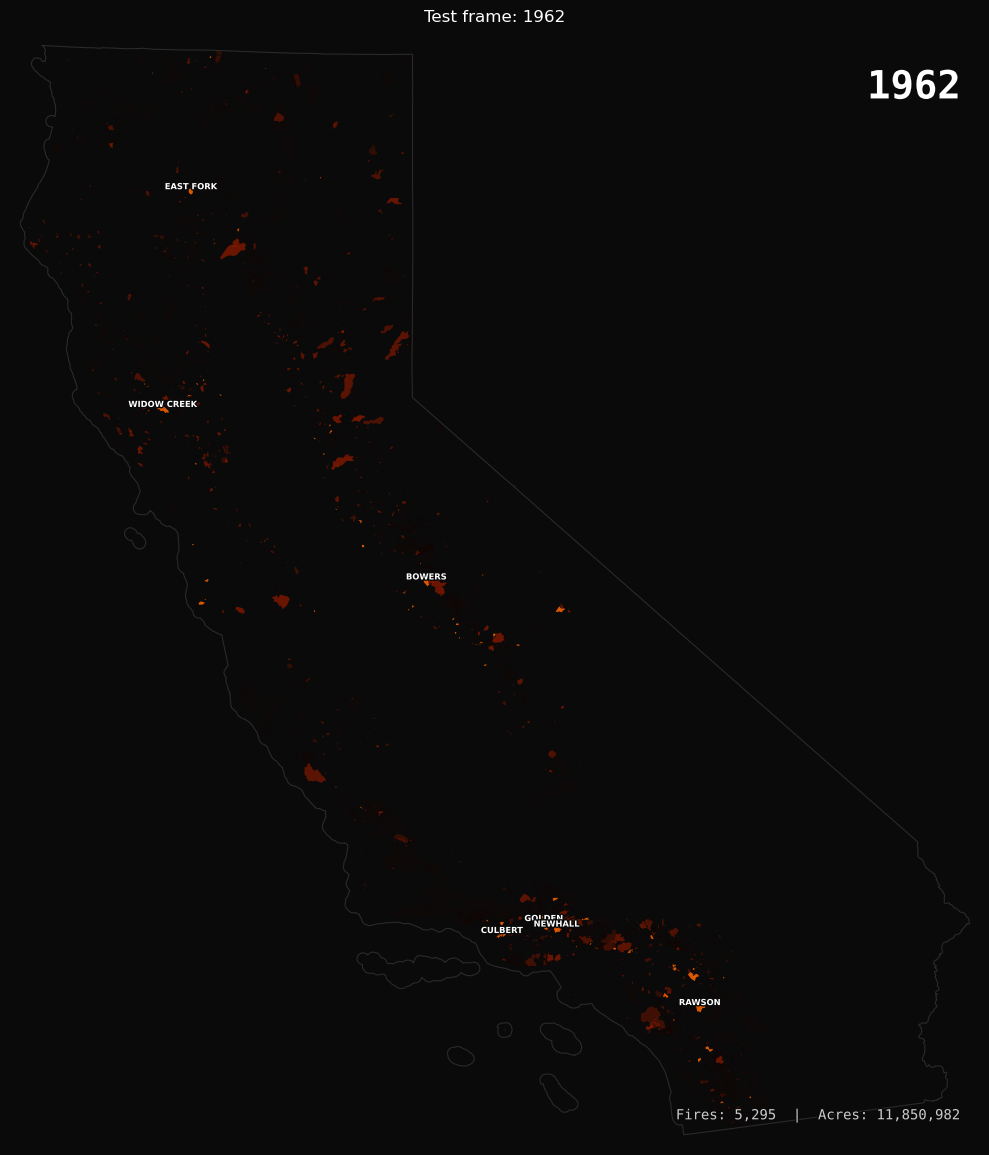

✓ Render function ready


In [21]:
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon as MplPolygon
from shapely.geometry import MultiPolygon, Polygon
import matplotlib.patheffects as pe

def get_display_year(time_bin: str) -> str:
    """Convert time_bin to a human-readable display string."""
    if "-" in str(time_bin):
        parts = str(time_bin).split("-")
        month_names = ["", "Jan", "Feb", "Mar", "Apr", "May", "Jun",
                       "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
        return f"{month_names[int(parts[1])]} {parts[0]}"
    return str(time_bin)


# Pre-compute YEARLY bins in addition to the adaptive (monthly where possible) bins
yearly_bins = sorted(gdf_interactive["year"].dropna().unique().astype(int).astype(str))
yearly_bin_to_indices = {}
for yr in yearly_bins:
    yearly_bin_to_indices[yr] = gdf_interactive[
        gdf_interactive["year"] == int(yr)
    ].index.tolist()

print(f"Adaptive bins (monthly where possible): {len(sorted_bins)}")
print(f"Yearly bins: {len(yearly_bins)}")


def render_frame(
    frame_idx: int,
    start_bin_idx: int,
    fade_frames: int,
    fade_mode: str,
    min_acres: float,
    label_fires: bool,
    use_yearly: bool,
    fig=None,
    ax=None,
):
    """
    Render a single animation frame. Optimized to use at most
    (fade_frames + 2) plot calls instead of one per historical bin.
    """
    if fig is None or ax is None:
        fig, ax = plt.subplots(figsize=(10, 14))

    ax.clear()
    ax.set_facecolor(BG_COLOR)
    fig.patch.set_facecolor(BG_COLOR)

    # Pick which bin system we're using
    bins = yearly_bins if use_yearly else sorted_bins
    bin_lookup = yearly_bin_to_indices if use_yearly else bin_to_indices

    # Draw California outline
    ca_boundary.boundary.plot(ax=ax, color=CA_OUTLINE_COLOR, linewidth=0.8)

    current_bin = bins[frame_idx]
    current_sort = time_bin_sort_key(current_bin)
    start_sort = time_bin_sort_key(bins[start_bin_idx])

    # Determine the fade window boundary
    fade_window_start = max(start_bin_idx, frame_idx - fade_frames)
    if fade_window_start > start_bin_idx:
        fade_boundary_sort = time_bin_sort_key(bins[fade_window_start])
    else:
        fade_boundary_sort = start_sort

    # === LAYER 1: Background fires (everything before fade window) ===
    # ONE single plot call instead of looping through hundreds of bins
    if fade_mode != "disappear" and fade_window_start > start_bin_idx:
        bg_mask = (
            (gdf_interactive["time_sort"] >= start_sort)
            & (gdf_interactive["time_sort"] < fade_boundary_sort)
        )
        if min_acres > 0:
            bg_mask = bg_mask & (gdf_interactive["acres"] >= min_acres)
        bg = gdf_interactive[bg_mask]
        if not bg.empty:
            color = FIRE_COLOR_GHOST if fade_mode == "ghost" else FIRE_COLOR_FADING
            alpha = 0.15 if fade_mode == "ghost" else 0.25
            bg.plot(ax=ax, color=color, alpha=alpha, linewidth=0)

    # === LAYER 2: Fading fires (recent bins within fade window) ===
    for bi in range(fade_window_start, frame_idx):
        tb = bins[bi]
        indices = bin_lookup.get(tb, [])
        if not indices:
            continue
        subset = gdf_interactive.loc[indices]
        if min_acres > 0:
            subset = subset[subset["acres"] >= min_acres]
        if subset.empty:
            continue
        frames_ago = frame_idx - bi
        t = frames_ago / fade_frames
        alpha = 0.85 * (1 - t) + 0.3 * t
        subset.plot(ax=ax, color=FIRE_COLOR_FADING, alpha=alpha, linewidth=0)

    # === LAYER 3: Active fires (current bin) ===
    active_indices = bin_lookup.get(current_bin, [])
    label_candidates = []
    if active_indices:
        active = gdf_interactive.loc[active_indices]
        if min_acres > 0:
            active = active[active["acres"] >= min_acres]
        if not active.empty:
            active.plot(ax=ax, color=FIRE_COLOR_ACTIVE, alpha=0.85, linewidth=0)
            if label_fires:
                for _, row in active.iterrows():
                    if row["acres"] >= LABEL_MIN_ACRES:
                        centroid = row.geometry.centroid
                        label_candidates.append(
                            (centroid.x, centroid.y, row["fire_name"])
                        )

    # Draw fire labels
    for x, y, name in label_candidates:
        ax.annotate(
            name, (x, y), fontsize=6, color="#ffffff", fontweight="bold",
            ha="center", va="bottom",
            path_effects=[pe.withStroke(linewidth=2, foreground=BG_COLOR)],
        )

    # Overlay: year/month display
    display_text = get_display_year(current_bin)
    ax.text(
        0.98, 0.97, display_text,
        transform=ax.transAxes, fontsize=28, fontweight="bold",
        color=YEAR_TEXT_COLOR, ha="right", va="top",
        fontfamily="monospace",
        path_effects=[pe.withStroke(linewidth=3, foreground=BG_COLOR)],
    )

    # Cumulative stats
    cum_mask = (
        (gdf_interactive["time_sort"] >= start_sort)
        & (gdf_interactive["time_sort"] <= current_sort)
    )
    if min_acres > 0:
        cum_mask = cum_mask & (gdf_interactive["acres"] >= min_acres)
    cum_fires = cum_mask.sum()
    cum_acres = gdf_interactive.loc[cum_mask, "acres"].sum()

    stats_text = f"Fires: {cum_fires:,}  |  Acres: {cum_acres:,.0f}"
    ax.text(
        0.98, 0.02, stats_text,
        transform=ax.transAxes, fontsize=10,
        color=TEXT_COLOR, ha="right", va="bottom",
        fontfamily="monospace",
        path_effects=[pe.withStroke(linewidth=2, foreground=BG_COLOR)],
    )

    ax.set_xlim(bounds[0] - 10000, bounds[2] + 10000)
    ax.set_ylim(bounds[1] - 10000, bounds[3] + 10000)
    ax.set_axis_off()
    ax.set_aspect("equal")

    return fig, ax


# Quick test
test_idx = len(yearly_bins) // 2
fig, ax = render_frame(
    frame_idx=test_idx, start_bin_idx=0, fade_frames=FADE_FRAMES,
    fade_mode="ghost", min_acres=100, label_fires=True, use_yearly=True,
)
ax.set_title(f"Test frame: {yearly_bins[test_idx]}", color=YEAR_TEXT_COLOR, fontsize=12, pad=10)
plt.tight_layout()
plt.show()
print("✓ Render function ready")

In [22]:
# Create control widgets
start_year_slider = pn.widgets.IntSlider(
    name="Start Year",
    start=int(gdf["year"].min()),
    end=int(gdf["year"].max()) - 10,
    value=ANIMATION_START_YEAR,
    step=10,
)

end_year_slider = pn.widgets.IntSlider(
    name="End Year",
    start=int(gdf["year"].min()) + 10,
    end=int(gdf["year"].max()),
    value=int(gdf["year"].max()),
    step=1,
)

min_acres_slider = pn.widgets.IntSlider(
    name="Min Acres Filter",
    start=0, end=10000, value=0, step=100,
)

fade_frames_slider = pn.widgets.IntSlider(
    name="Fade Duration (frames)",
    start=1, end=20, value=FADE_FRAMES, step=1,
)

fade_mode_toggle = pn.widgets.RadioButtonGroup(
    name="Fade Mode",
    options=["disappear", "ghost", "stay"],
    value="ghost",
    button_type="default",
)

label_toggle = pn.widgets.Toggle(
    name="Label Large Fires", value=True, button_type="default",
)

# Speed slider: 1=slowest, 10=fastest (right side = fast)
speed_slider = pn.widgets.IntSlider(
    name="Speed (1=slow, 10=fast)",
    start=1, end=10, value=5, step=1,
)

resolution_toggle = pn.widgets.RadioButtonGroup(
    name="Resolution",
    options=["yearly", "monthly"],
    value="yearly",
    button_type="default",
)

def get_filtered_bins(start_year, end_year, use_yearly=True):
    """Return bin indices within the year range."""
    bins = yearly_bins if use_yearly else sorted_bins
    filtered = []
    for i, tb in enumerate(bins):
        sort_key = time_bin_sort_key(tb)
        if start_year <= sort_key < end_year + 1:
            filtered.append(i)
    return filtered

def speed_to_interval(speed_val):
    """Convert speed 1-10 to ms interval. 1=1000ms, 10=50ms."""
    return int(1000 - (speed_val - 1) * (950 / 9))

use_yearly = True
initial_bins = get_filtered_bins(start_year_slider.value, end_year_slider.value, use_yearly)

player = pn.widgets.Player(
    name="Timeline",
    start=0,
    end=len(initial_bins) - 1,
    value=0,
    interval=speed_to_interval(speed_slider.value),
    step=1,
    loop_policy="once",
    width=600,
    show_loop_controls=True,
)

status_pane = pn.pane.Markdown("Ready", styles={"color": "#cccccc"})

app_fig, app_ax = plt.subplots(figsize=(10, 14))
plt.close(app_fig)

mpl_pane = pn.pane.Matplotlib(app_fig, tight=True, dpi=100, sizing_mode="stretch_height")

def do_update(*events):
    is_yearly = resolution_toggle.value == "yearly"
    filtered_bin_indices = get_filtered_bins(
        start_year_slider.value, end_year_slider.value, is_yearly
    )
    pv = player.value
    if not filtered_bin_indices or pv >= len(filtered_bin_indices):
        return

    frame_idx = filtered_bin_indices[pv]
    start_bin_idx = filtered_bin_indices[0]
    bins = yearly_bins if is_yearly else sorted_bins

    render_frame(
        frame_idx=frame_idx,
        start_bin_idx=start_bin_idx,
        fade_frames=fade_frames_slider.value,
        fade_mode=fade_mode_toggle.value,
        min_acres=min_acres_slider.value,
        label_fires=label_toggle.value,
        use_yearly=is_yearly,
        fig=app_fig,
        ax=app_ax,
    )

    current_bin = bins[frame_idx]
    mode_label = "yearly" if is_yearly else "monthly"
    status_pane.object = (
        f"**Frame {pv + 1} / {len(filtered_bin_indices)}** — "
        f"**{get_display_year(current_bin)}** — "
        f"{mode_label} mode, {len(filtered_bin_indices)} frames"
    )

    mpl_pane.param.trigger("object")

# Watch all widgets
player.param.watch(do_update, "value")
min_acres_slider.param.watch(do_update, "value")
fade_frames_slider.param.watch(do_update, "value")
fade_mode_toggle.param.watch(do_update, "value")
label_toggle.param.watch(do_update, "value")

def update_player_range(*events):
    is_yearly = resolution_toggle.value == "yearly"
    filtered = get_filtered_bins(
        start_year_slider.value, end_year_slider.value, is_yearly
    )
    if filtered:
        player.end = len(filtered) - 1
        player.value = min(player.value, player.end)
    do_update()

start_year_slider.param.watch(update_player_range, "value")
end_year_slider.param.watch(update_player_range, "value")
resolution_toggle.param.watch(update_player_range, "value")

def update_speed(event):
    player.interval = speed_to_interval(event.new)

speed_slider.param.watch(update_speed, "value")

do_update()
print("✓ Panel app built. Run the next cell to display it.")

✓ Panel app built. Run the next cell to display it.


In [23]:
controls = pn.Column(
    pn.pane.Markdown("## 🔥 California Fire History Explorer", styles={"color": "#ff6600"}),
    pn.pane.Markdown(
        "Use the player controls to animate through fire history. "
        "Adjust filters and settings below.",
        styles={"color": "#cccccc"},
    ),
    player,
    pn.Row(speed_slider, pn.Column(pn.pane.Markdown("**Resolution:**"), resolution_toggle)),
    pn.layout.Divider(),
    pn.Row(start_year_slider, end_year_slider),
    pn.Row(min_acres_slider, fade_frames_slider),
    pn.Row(
        pn.Column(pn.pane.Markdown("**Fade Mode:**"), fade_mode_toggle),
        label_toggle,
    ),
    pn.layout.Divider(),
    status_pane,
    width=620,
)

app_layout = pn.Row(
    controls,
    mpl_pane,
    sizing_mode="stretch_width",
    min_height=800,
)

app_layout.servable()
app_layout

BokehModel(combine_events=True, render_bundle={'docs_json': {'cdfec3d1-eff5-4456-ab4c-ec0a19b54e76': {'version…

### How to use the explorer:

1. **Play/Pause**: Use the player controls (▶ / ⏸) to animate through time
2. **Scrub**: Drag the player slider to jump to any point in the timeline
3. **Speed**: Adjust "Speed (ms per frame)" — lower = faster
4. **Year Range**: Filter to focus on a specific era
5. **Min Acres**: Filter out small fires to reduce clutter
6. **Fade Mode**:
   - *disappear*: fires vanish after fading — keeps map clean
   - *ghost*: fires leave a very faint trace — shows cumulative burn area
   - *stay*: fires fade to dark red and remain — builds up a "scar map"
7. **Label Large Fires**: Toggle fire name labels for fires ≥ 5,000 acres

### Exporting:
To save as a standalone HTML file you can share:
```python
app_layout.save("fire_history_explorer.html", embed=True)
```

In [24]:
html_path = OUTPUT_DIR / "fire_history_explorer.html"
try:
    app_layout.save(str(html_path), embed=True)
    print(f"✓ Exported interactive app: {html_path}")
    print(f"  File size: {html_path.stat().st_size / 1e6:.1f} MB")
    print(f"  Open in any browser to explore!")
except Exception as e:
    print(f"⚠️  HTML export failed: {e}")
    print(f"  This is common if the state is too large to embed.")
    print(f"  The app works fine in the notebook — use it here instead.")

KeyboardInterrupt: 